In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import sys
import random
import re
import json

# ============================================================
# 1. 고정 경로 설정
# ============================================================

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

SIDE_PROJECT_DIR = BASE_DIR / 'synthetic_scenarios' / 'side'
LABELER_DIR = BASE_DIR / 'synthetic_scenarios'

COMMON_FILE = SIDE_PROJECT_DIR / 'side_synthetic_shelf_common.py'
LABELER_FILE = LABELER_DIR / 'synthetic_label_exporter.py'

if not COMMON_FILE.exists():
    raise FileNotFoundError(f'측면 공통 py 파일을 찾지 못했습니다: {COMMON_FILE}')

if not LABELER_FILE.exists():
    raise FileNotFoundError(f'라벨 exporter 파일을 찾지 못했습니다: {LABELER_FILE}')

if str(SIDE_PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(SIDE_PROJECT_DIR))

if str(LABELER_DIR) not in sys.path:
    sys.path.insert(0, str(LABELER_DIR))

import side_synthetic_shelf_common as synth
import synthetic_label_exporter as labeler

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_사이드.png',
    seed=42,
)

print('측면 공통 py:', COMMON_FILE)
print('라벨 exporter:', LABELER_FILE)
print('BASE_DIR:', BASE_DIR)
print('slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))

측면 공통 py: /content/drive/MyDrive/먼작귀/synthetic_scenarios/side/side_synthetic_shelf_common.py
라벨 exporter: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
slot 수: 12
class 수: 38


In [3]:
# ============================================================
# S0 설정 + 저장 경로
# ============================================================

SCENARIO_CODE = 'S0'
SCENARIO_NAME = '정상 진열'
NUM_IMAGES = 280
BASE_SEED = 100260

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'side' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'side' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'side' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'side' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def get_next_start_index(image_dir, scenario_code):
    image_dir = Path(image_dir)
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3,5}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1


start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None

print('IMAGE_DIR:', IMAGE_DIR)
print('PRODUCT_YOLO_DIR:', PRODUCT_YOLO_DIR)
print('SHELF_LIP_YOLO_DIR:', SHELF_LIP_YOLO_DIR)
print('JSON_DIR:', JSON_DIR)
print('start_idx:', start_idx)

IMAGE_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s0
PRODUCT_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s0
SHELF_LIP_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s0
JSON_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/side/s0
start_idx: 1


[PNG 선택: S_ROW_KEYWORD] 65027 | row_1 | 30_s_24 | 65027_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15088 | row_1 | 30_s_24 | 15088_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35828 | row_1 | 30_s_23 | 35828_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 20186 | row_2 | 30_s_23 | 20186_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35763 | row_2 | 30_s_23 | 35763_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10170 | row_2 | 30_s_23 | 10170_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10098 | row_3 | 30_s_24 | 10098_30_s_24_sam_object_crop.png
[PNG 선택: FORCE_KEYWORD] 25425 | row_3 | 30_s_21 | 25425_30_s_21_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10160 | row_3 | 30_s_24 | 10160_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 65327 | row_4 | 30_s_24 | 65327_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 75061 | row_4 | 30_s_24 | 75061_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35872 | row_4 | 30_s_24 | 35872_30_s_24_sam_object_c

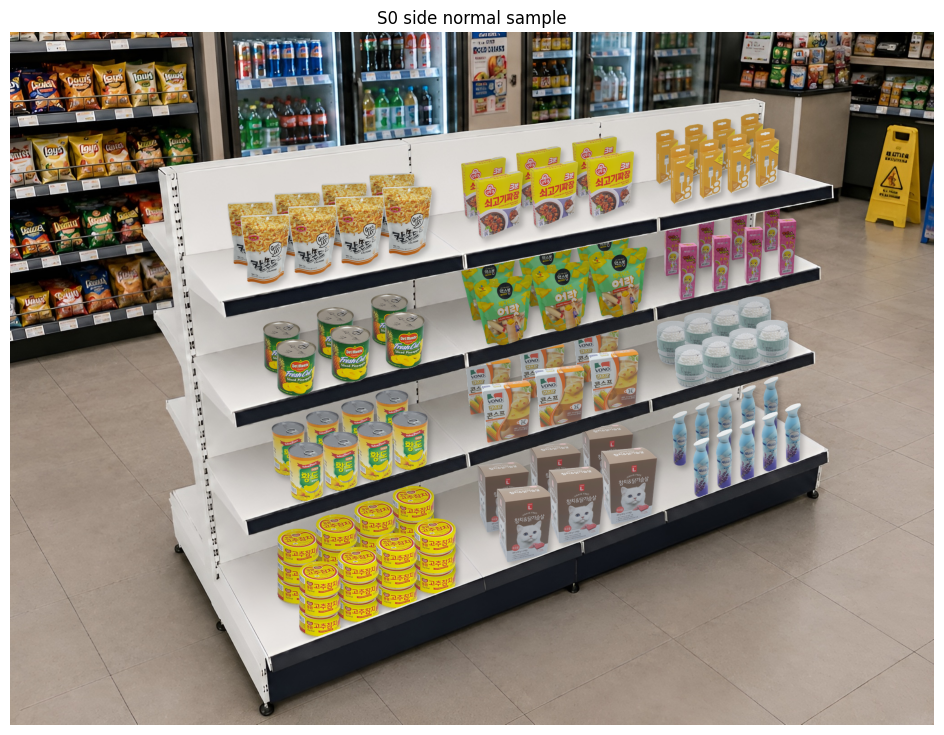

In [4]:
# ============================================================
# S0 측면 이미지 + 라벨 생성
# ============================================================

for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx

    random.seed(seed)
    synth.reset_random_seed(seed)

    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_사이드.png',
        seed=seed,
    )

    # S0: 정상 진열
    slot_plan = synth.make_normal_slot_plan(ctx)

    for slot_id, target in slot_plan.items():
        normal_front_qty = int(target['normal_front_qty'])
        normal_back_qty = int(target['normal_back_qty'])

        target.update({
            'scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'normal',
            'list_up': False,
            'final_status': '정상',

            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'missing_qty': 0,
            'reduced_front_qty': normal_front_qty,
            'target_column_index': None,
            'is_misplaced': False,
        })

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed
    )

    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='side',
    )

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0:
        print(f'[{image_idx + 1}/{NUM_IMAGES}] 생성 완료:', save_name)

print('S0 생성 완료')
print('총 생성 수:', len(saved_paths))
print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} side normal sample')